In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_balance_sheet.csv
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_company_info.csv
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_stock_prices.csv
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_dividends.csv
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/README.md
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_financials.csv
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_sec_filings.csv
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/DATASET_METADATA.md
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_cash_flow.csv
/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_nasdaq_data.csv


# Problem Statement

Stock prices are difficult to predict due to market volatility, nonlinear patterns, and time-dependent behavior. The goal is to use historical stock data to build machine learning and deep learning models that can predict future price movements more accurately.

**Why AI Adoption Matters**

AI models can capture complex patterns and temporal relationships in financial data that traditional methods often miss, enabling better forecasting and data-driven decision making.

**Objectives of this Notebook**

- Perform EDA to understand stock trends.

- Build multiple ML and DL models (RF, XGBoost, LSTM, GRU).

- Compare model performance using metrics like MSE and R².

- Visualize predictions and errors to evaluate model behavior.

In [2]:

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xgb
import shap
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout

sns.set_style("whitegrid")

E0000 00:00:1773401295.480532      17 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773401295.540679      17 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773401296.085306      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773401296.085415      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773401296.085419      17 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773401296.085422      17 computation_placer.cc:177] computation placer already registered. Please check linka

In [3]:
import pandas as pd


df = pd.read_csv("/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_stock_prices.csv")


print("Columns:", df.columns)
print("First 5 rows:\n", df.head())
print("\nMissing values per column:\n", df.isnull().sum())


df['Date'] = pd.to_datetime(df['Date'])


df = df.sort_values('Date')


df = df[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()



Columns: Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends',
       'Stock Splits'],
      dtype='object')
First 5 rows:
                         Date      Open      High       Low     Close  Volume  \
0  1972-06-01 00:00:00-04:00  1.224211  1.224211  1.224211  1.224211       0   
1  1972-06-02 00:00:00-04:00  1.218877  1.218877  1.218877  1.218877       0   
2  1972-06-05 00:00:00-04:00  1.194874  1.194874  1.194874  1.194874       0   
3  1972-06-06 00:00:00-04:00  1.130862  1.130862  1.130862  1.130862       0   
4  1972-06-07 00:00:00-04:00  1.117527  1.117527  1.117527  1.117527       0   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  

Missing values per column:
 Date            0
Open            0
High            0
Low             0
Close           0
Volume          0
Dividends       0
Stock Splits    0
dtype: int64


#  Load Dataset

In [4]:
df = pd.read_csv("/kaggle/input/datasets/anadiskt/american-express-axp-stock-data-19722026/axp_stock_prices.csv")
df['Date'] = pd.to_datetime(df['Date'], utc=True)
df = df.sort_values('Date').reset_index(drop=True)
df = df[['Date','Open','High','Low','Close','Volume','Dividends','Stock Splits']]

#  Feature Engineering

In [5]:

df['Close_lag1'] = df['Close'].shift(1)
df['Close_lag2'] = df['Close'].shift(2)
df['Volume_lag1'] = df['Volume'].shift(1)
df['Volume_lag2'] = df['Volume'].shift(2)
df['MA_5'] = df['Close'].rolling(5).mean()
df['MA_10'] = df['Close'].rolling(10).mean()
df['MA_20'] = df['Close'].rolling(20).mean()
delta = df['Close'].diff()
gain = np.where(delta>0, delta, 0)
loss = np.where(delta<0, -delta, 0)
avg_gain = pd.Series(gain).rolling(14).mean()
avg_loss = pd.Series(loss).rolling(14).mean()
rs = avg_gain/avg_loss
df['RSI_14'] = 100-(100/(1+rs))
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['MACD_Signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
df['BB_Mid'] = df['Close'].rolling(20).mean()
df['BB_Upper'] = df['BB_Mid'] + 2*df['Close'].rolling(20).std()
df['BB_Lower'] = df['BB_Mid'] - 2*df['Close'].rolling(20).std()

df = df.dropna()

features = ['Open','High','Low','Volume','Dividends','Stock Splits',
            'Close_lag1','Close_lag2','Volume_lag1','Volume_lag2',
            'MA_5','MA_10','MA_20','RSI_14','MACD','MACD_Signal','BB_Upper','BB_Lower']
target = 'Close'

X = df[features]
y = df[target]


#  Train/Test Split

In [6]:
split_idx = int(len(df)*0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#  ML + Stacking Ensemble

In [7]:
rf = RandomForestRegressor(n_estimators=200, random_state=42)
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xg = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
stack = StackingRegressor(estimators=[('rf',rf),('gb',gb),('xg',xg)], final_estimator=LinearRegression())

ml_models = {'Random Forest':rf, 'Gradient Boosting':gb, 'XGBoost':xg, 'Stacking':stack}
results = {}

for name, model in ml_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    results[name] = {'MSE': mean_squared_error(y_test,preds), 'R2': r2_score(y_test,preds)}

#  SHAP Feature Importance (Random Forest)

100%|===================| 2704/2708 [04:23<00:00]       

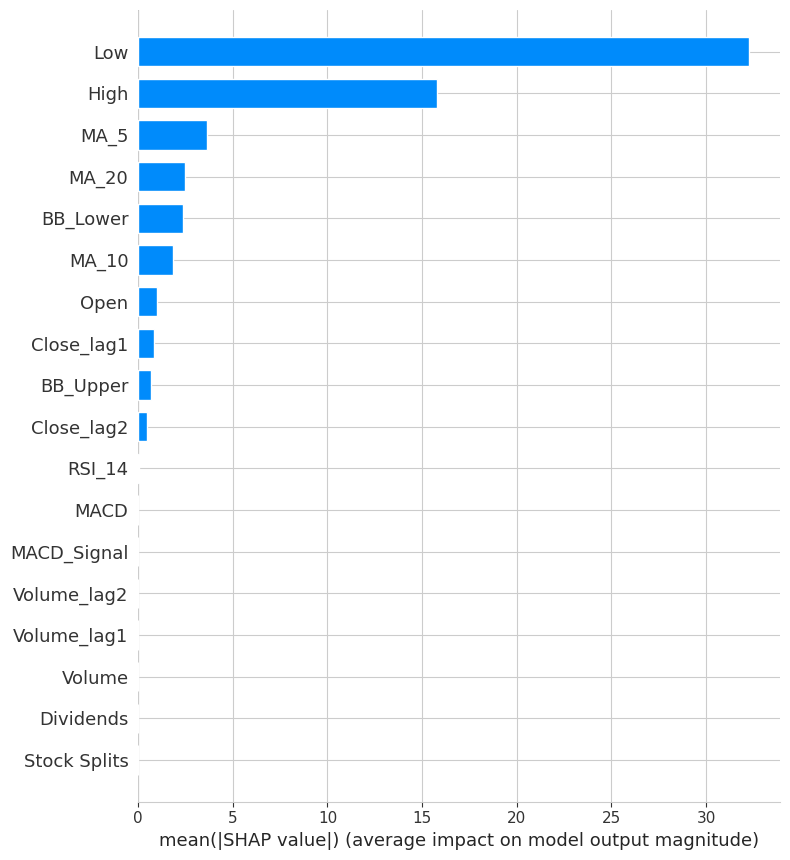

In [8]:

explainer = shap.Explainer(rf, X_train_scaled)
shap_values = explainer(X_test_scaled)
shap.summary_plot(shap_values, X_test, plot_type='bar', show=True)

#  Prepare LSTM/GRU Sequences

In [9]:

scaler_dl = MinMaxScaler()
X_scaled_dl = scaler_dl.fit_transform(X)
y_scaled_dl = scaler_dl.fit_transform(y.values.reshape(-1,1))

def create_sequences(X,y,seq_len=10):
    X_seq,y_seq=[],[]
    for i in range(seq_len,len(X)):
        X_seq.append(X[i-seq_len:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

seq_len = 10
X_seq, y_seq = create_sequences(X_scaled_dl, y_scaled_dl, seq_len)
split_seq = int(len(X_seq)*0.8)
X_train_seq, X_test_seq = X_seq[:split_seq], X_seq[split_seq:]
y_train_seq, y_test_seq = y_seq[:split_seq], y_seq[split_seq:]

#  LSTM / GRU Models

In [10]:
def build_rnn(model_type='LSTM', units=64, dropout=0.2):
    model = Sequential()
    if model_type=='LSTM':
        model.add(LSTM(units, activation='tanh', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
    else:
        model.add(GRU(units, activation='tanh', input_shape=(X_train_seq.shape[1], X_train_seq.shape[2])))
    model.add(Dropout(dropout))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    return model

lstm_model = build_rnn('LSTM')
lstm_model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
preds_lstm_inv = scaler_dl.inverse_transform(lstm_model.predict(X_test_seq))
y_test_inv = scaler_dl.inverse_transform(y_test_seq)
results['LSTM'] = {'MSE': mean_squared_error(y_test_inv,preds_lstm_inv),
                   'R2': r2_score(y_test_inv,preds_lstm_inv)}

gru_model = build_rnn('GRU')
gru_model.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, validation_split=0.1, verbose=0)
preds_gru_inv = scaler_dl.inverse_transform(gru_model.predict(X_test_seq))
results['GRU'] = {'MSE': mean_squared_error(y_test_inv,preds_gru_inv),
                  'R2': r2_score(y_test_inv,preds_gru_inv)}

85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


#  Align Dates for DL Predictions

In [11]:
test_dates_seq = df['Date'][split_idx+seq_len : split_idx+seq_len+len(preds_lstm_inv)]

#  Plotting with Confidence Intervals

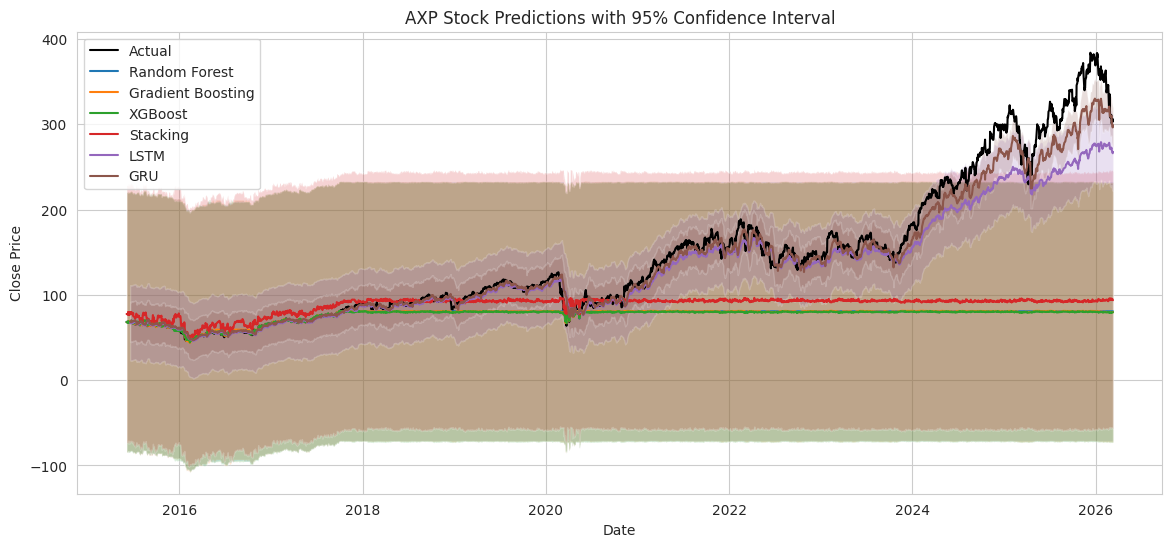

In [12]:
def plot_with_uncertainty(y_true, y_pred, dates, label):
    y_true = y_true.ravel()
    y_pred = y_pred.ravel()
    dates = np.array(dates)
    min_len = min(len(y_true), len(y_pred), len(dates))
    y_true, y_pred, dates = y_true[:min_len], y_pred[:min_len], dates[:min_len]
    errors = y_true - y_pred
    ci_upper = y_pred + 1.96*np.std(errors)
    ci_lower = y_pred - 1.96*np.std(errors)
    plt.plot(dates, y_pred, label=label)
    plt.fill_between(dates, ci_lower, ci_upper, alpha=0.2)

plt.figure(figsize=(14,6))
plt.plot(df['Date'][split_idx:], y_test.values, color='black', label='Actual')

for name, model in ml_models.items():
    preds = model.predict(X_test_scaled)
    plot_with_uncertainty(y_test.values, preds, df['Date'][split_idx:], label=name)

plot_with_uncertainty(y_test_inv, preds_lstm_inv, test_dates_seq, 'LSTM')
plot_with_uncertainty(y_test_inv, preds_gru_inv, test_dates_seq, 'GRU')

plt.title("AXP Stock Predictions with 95% Confidence Interval")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


##  Predictions vs Actual

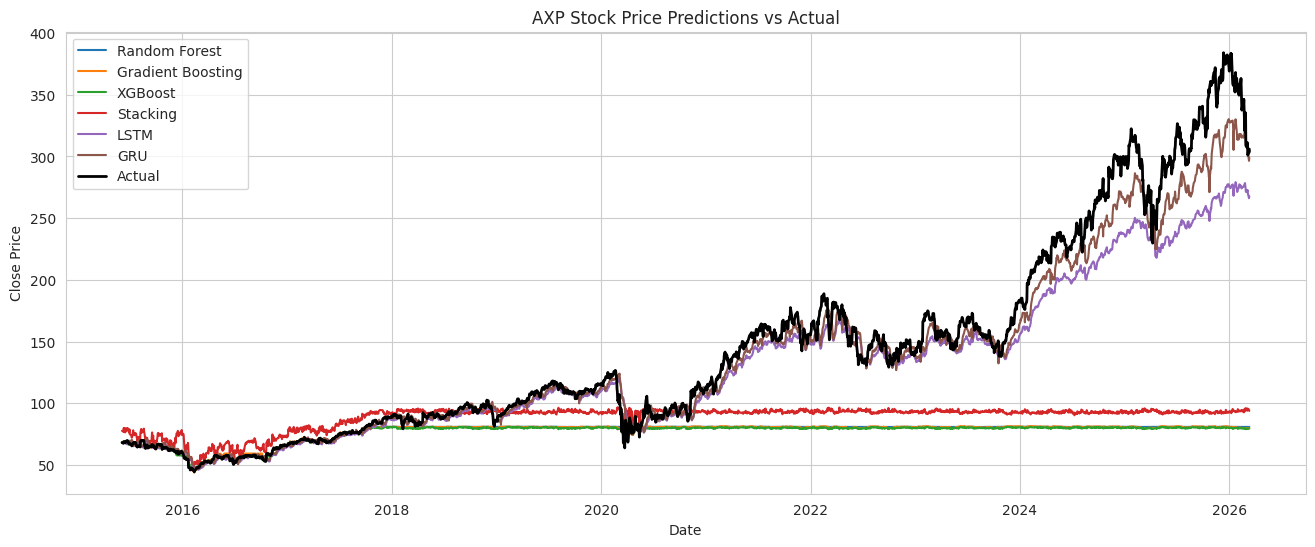

In [13]:
import matplotlib.dates as mdates

def trim_arrays(dates, y1, y2):
    min_len = min(len(dates), len(y1), len(y2))
    return dates[:min_len], y1[:min_len], y2[:min_len]


plt.figure(figsize=(16,6))

# Classical ML
for name, model in ml_models.items():
    preds = model.predict(X_test_scaled)
    d, y_true, y_pred = trim_arrays(df['Date'][split_idx:], y_test.values, preds)
    plt.plot(d, y_pred, label=name)

# LSTM
d, y_true, y_pred = trim_arrays(test_dates_seq, y_test_inv.ravel(), preds_lstm_inv.ravel())
plt.plot(d, y_pred, label="LSTM")

# GRU
d, y_true, y_pred = trim_arrays(test_dates_seq, y_test_inv.ravel(), preds_gru_inv.ravel())
plt.plot(d, y_pred, label="GRU")

plt.plot(df['Date'][split_idx:], y_test.values, color='black', linewidth=2, label="Actual")

plt.title("AXP Stock Price Predictions vs Actual")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()
plt.show()


## Residuals Over Time

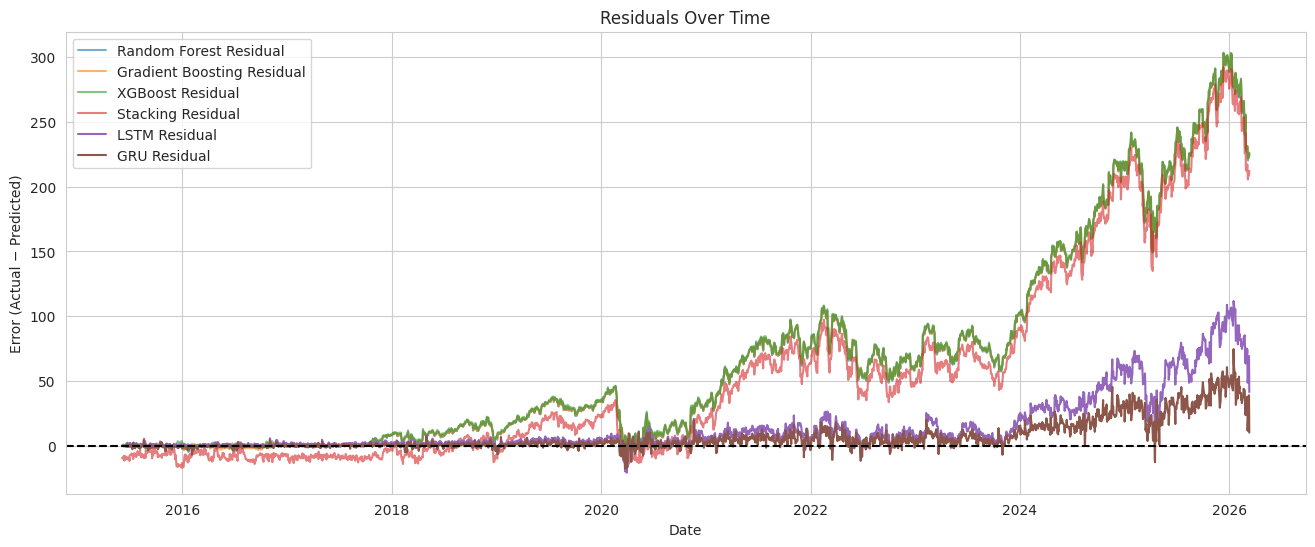

In [14]:

plt.figure(figsize=(16,6))

# Classical ML residuals
for name, model in ml_models.items():
    preds = model.predict(X_test_scaled)
    d, y_true, y_pred = trim_arrays(df['Date'][split_idx:], y_test.values, preds)
    residuals = y_true - y_pred
    plt.plot(d, residuals, label=f"{name} Residual", alpha=0.6)

# LSTM residuals
d, y_true, y_pred = trim_arrays(test_dates_seq, y_test_inv.ravel(), preds_lstm_inv.ravel())
plt.plot(d, y_true - y_pred, label="LSTM Residual")

# GRU residuals
d, y_true, y_pred = trim_arrays(test_dates_seq, y_test_inv.ravel(), preds_gru_inv.ravel())
plt.plot(d, y_true - y_pred, label="GRU Residual")

plt.axhline(0, color='black', linestyle='--')
plt.title("Residuals Over Time")
plt.xlabel("Date")
plt.ylabel("Error (Actual − Predicted)")
plt.legend()
plt.show()

## Error Distribution

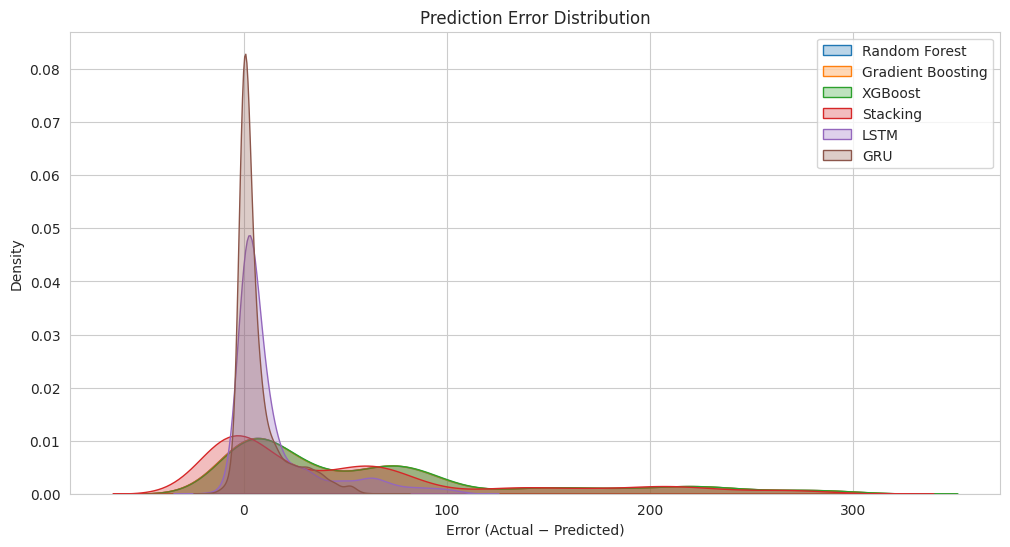

In [15]:

plt.figure(figsize=(12,6))

for name, model in ml_models.items():
    preds = model.predict(X_test_scaled)
    errors = y_test.values - preds
    sns.kdeplot(errors, label=name, fill=True, alpha=0.3)

# LSTM
min_len = min(len(y_test_inv), len(preds_lstm_inv))
lstm_errors = y_test_inv.ravel()[:min_len] - preds_lstm_inv.ravel()[:min_len]
sns.kdeplot(lstm_errors, label="LSTM", fill=True, alpha=0.3)

# GRU
min_len = min(len(y_test_inv), len(preds_gru_inv))
gru_errors = y_test_inv.ravel()[:min_len] - preds_gru_inv.ravel()[:min_len]
sns.kdeplot(gru_errors, label="GRU", fill=True, alpha=0.3)

plt.title("Prediction Error Distribution")
plt.xlabel("Error (Actual − Predicted)")
plt.ylabel("Density")
plt.legend()
plt.show()


##  Feature Correlation Heatmap

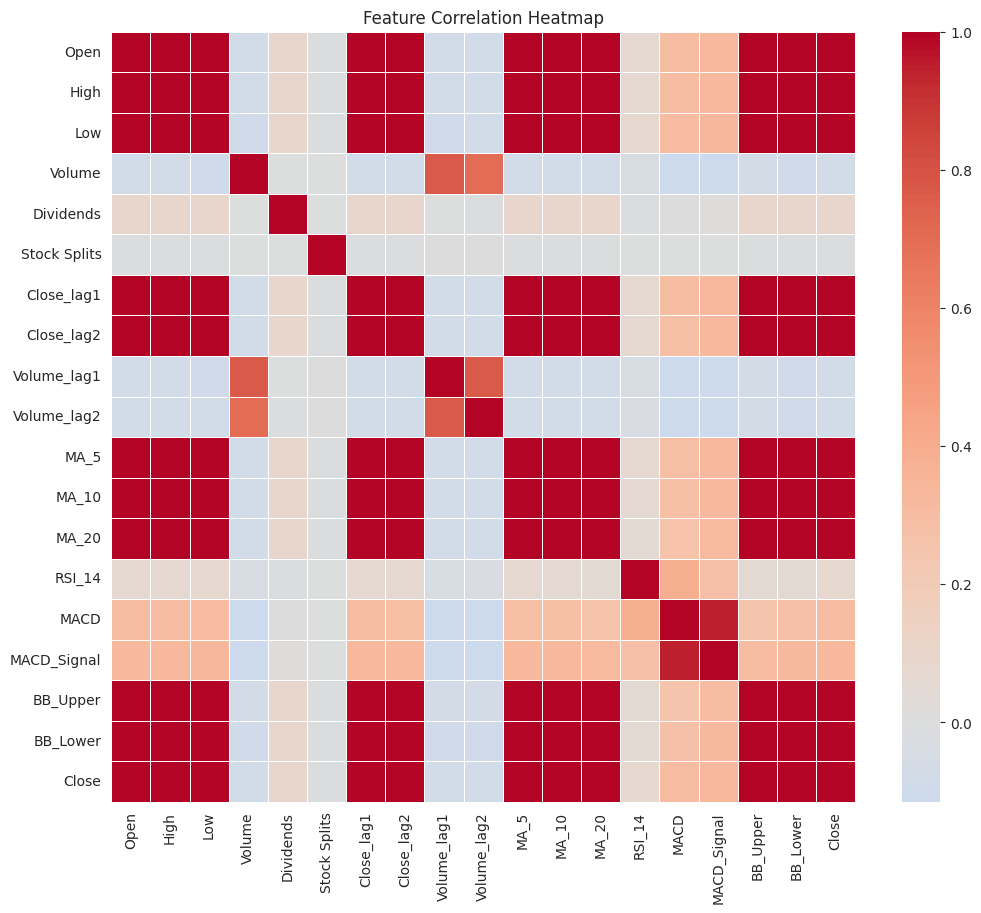

In [16]:

plt.figure(figsize=(12,10))

corr = df[features + ['Close']].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

#  Final Results Table

In [17]:

results_df = pd.DataFrame(results).T.sort_values('R2',ascending=False)
print("\n Model Comparison ")
print(results_df)


 Model Comparison 
                            MSE        R2
GRU                  188.361921  0.971462
LSTM                 709.623588  0.892489
Stacking            8913.092582 -0.350524
Random Forest      10378.833461 -0.572615
Gradient Boosting  10396.876326 -0.575349
XGBoost            10482.841866 -0.588375


# Overall Summary

**Why we do this:**
To understand stock market patterns and improve stock price prediction using AI models.

**What we do:**

- Perform EDA to explore trends in the data.

- Create features (lag values, indicators).

- Train multiple ML and DL models (Random Forest, XGBoost, LSTM, GRU).

- Compare model performance using evaluation metrics and visualizations.

**What we can do with this:**

- Forecast future stock prices.

- Support data-driven investment decisions.

- Improve models by adding more features, indicators, or advanced AI models.